<a href="https://colab.research.google.com/github/praksb2428-maker/Deep.practice/blob/main/d_l_Project_md.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트 제안서

### 개요
1. 기상청 데이터 기반 서울 7월의 평균온도, 최저온도, 최고온도 를 예측하는 모델링

2. 사용할 알고리즘 :  CNN-LSTM, GRU
- CNN: 급변을 인식하는 데 사용
- LSTM: 16년 7월 패턴 장기 기억
- CNN-LSTM : CNN과 LSTM을 동시에 사용하는 하이브리드 모델, 16년치 7월 데이터 = 장기 패턴 + 국소 변동성 모두 필요
- GRU : CNN-LSTM 보다 연산결과가 빠르기에 결과를 먼저 보기위해 사용

3. 사용할 라이브러리 : Numpy, Pandas, Scikit-learn, Matplotlib/Seaborn
- Numpy : 배열 연산, 결측치 보간
- Pandas : 파일을 가져와서 모델을 학습
- Scikit-learn : 데이터 전처리, 평가지표, 모델 비교
- Matplotlib/Seaborn : 데이터 탐색, 결과 검증

### 배경
- 7월의 온도를 분석하여 일의 온도를 예측하게 된 배경는 7월은 폭염으로 인한 열사병 발생 확률이 높은 계절이다. 이러한 폭염의 위험을 알리기 위해 우리에게는 재난 문자라는 "폭염주의보" 라는 문자가 온다. 이 문자는 외출을 자제하라는 메시지다. 나는 그저 외출을 자제하는 것이 아닌 온도를 확인하여 외출의 여부를 자신이 판단하고싶기에 만들게 되었다.

### 목표
- 과거 2010~2025 16년의 기상청 데이터를 기반으로 모델에 학습시켜서 7월 일 의 기온을 예측하여 평균온도, 최저온도, 최고온도를 출력하는 모델을 만드는 것

###  데이터셋 크기
| Dataset | 행 수 | 열 수 | 파일 크기 |
|---------|-------|-------|-----------|
| **DailyDelhiClimateTrain.csv** | **1,463** | **5** | **76.4 KB** |
| **DailyDelhiClimateTest.csv** | **1,144** | **5** | **6.9 KB** |

### 출처
- 원본: [Daily Climate time series data](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)
- 참고 구현: [LSTM/CNN 노트북](https://www.kaggle.com/code/ibrahimnibrahim/daily-climate-time-series-lstm-and-cnn)

### 데이터 기간
인도, 델리 (2013-2017)
- 학습셋: ~1,463일
- 테스트셋: 1,144일

### DailyDelhiClimateTest 컬럼
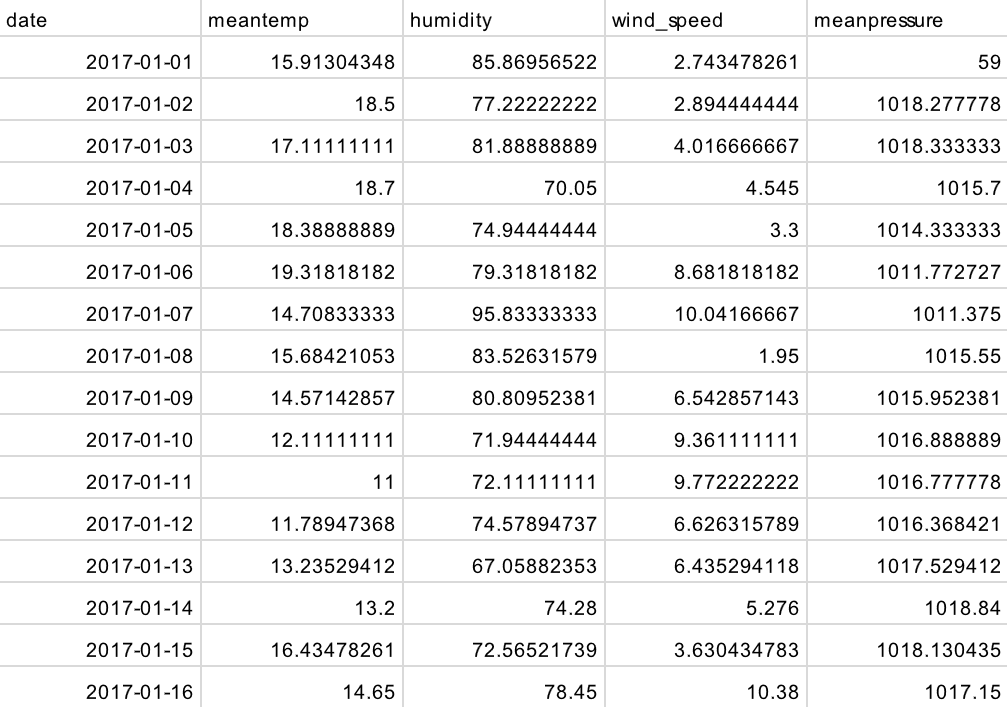

### 전처리 방법
1. 단순하게 df.dropna()로 해당 행을 제거, 또는 평균 / 선형 보간 등으로 대체

2. 정규화/스케일링 방식을 바꾸는 방법

3. MinMaxScaler 대신 Z‑score (StandardScaler) : 평균을 0, 분산을 1로 만들어서 이상치에 영향을 덜 받게 합니다.

4. RobustScaler : 중앙값과 IQR을 기준으로 스케일링해서, 폭우·폭염 같은 극단치에 훨씬 덜 민감합니다.

### 기존 프로젝트 개선점
1. kaggle에 있는 "Daily Climate(time series LSTM and CNN)" 이라는 프로젝트를 참고하여 개선할 점은 입력변수를 추가하여 성능을 올리는 방법


2. RMSE말고도 성능을 평가하는 알고리즘 MAE, R², MAPE 등을 함께 사용하여 평가
- MAE (Mean Absolute Error), °C온도 : 예측값과 실제값의 차이를 절댓값으로 해서 평균낸 값, 직관적, 이상치 덜 민감
- R²(결정계수), 0~1 : 모델이 데이터의 변동성을 몇 % 설명하는지, 모델 신뢰도가 1에 가까울수록 좋음
- MAPE (Mean Absolute Percentage Error), %의미 : 오차를 실제값 대비 백분율로 표현, 스케일 독립적, 수치가 0근처일 때 주의


### 데이터셋 주요기능
1. kaggle의 있는 "Daily Climate(time series LSTM and CNN)"과의 차이는 16년의 장기 데이터를 응용하여 7월 특화적 일 평균온도를 예측하는 것이다.

### 데이터셋

- 기간: 2010년 7월 1일 ~ 2025년 7월 31일 (16년)
- 지역: 서울특별시
- 데이터 형식: 일 단위 기온 데이터 (평균, 최저, 최고)
- 데이터 수: 16년 × 31일 = 496일
- 컬럼:
  - date: 날짜
  - avg_temp: 일 평균 기온 (°C)
  - min_temp: 일 최저 기온 (°C)
  - max_temp: 일 최고 기온 (°C)

이 데이터셋을 사용하여, 2026년 7월 nn일을 입력하면 해당 날짜의 평균, 최저, 최고 기온을 예측하는 모델

### 데이터 eda시각화

2010~2025년 7월의 평균 온도를 시각화

![7월 온도 분석](Code_Generated_Image.png)

### 사용 예시

상황

        일반인(예: 서울 거주자)이

            “2026년 7월 12일 기온이 얼마나 될지 미리 알고 싶다”

            비 오는지, 덥냐 안 더운지 대략 파악.

사용 예시

        2026년 7월 12일을 입력

        모델 출력:

            평균 기온: 28.1°C

            최저 기온: 24.5°C

            최고 기온: 31.2°C

        이 결과를 바탕으로

            “당일 30도 이상까지 오를 수 있으니 더위 대비”

### 기대효과
7월중 사람들이 폭염주의보 재난문자를 받고도 실질적으로 필요한 외출을 판단여부를 가능하게 될 것이다.

### 향후 일정
2026.04.27

기상청 데이터포털 접속 → 서울 2010~2025년 7월 CSV 다운로드
Pandas로 데이터 로드/탐색 (결측치, 통계)
7월 데이터만 추출 + 기본 시각화 (Matplotlib)

2026.04.30

- TimeSeriesSplit 검증셋 구성
- CNN-LSTM 입력 배열 생성 (window=14)

2026.05.04

- CNN-GRU 모델 구현 (Kaggle 코드 수정)
- MAE/R² 4지표 평가
- 결과 시각화 + 베이스라인 확보

2026.05.11

- CNN-LSTM 모델 구현 (Kaggle 원본 기반)
- 4지표 평가
- CNN-GRU vs CNN-LSTM 성능 비교

2026.05.18

- 0.7*LSTM + 0.3*GRU 앙상블 테스트
- EarlyStopping, Dropout 과적합 방지
 -하이퍼파라미터 튜닝 (window, units)

2026.05.26

- 성능표, 그래프 완성 (실제vs예측)
- README.md
- 2026년 7월 예측 테스트

2026.05.29

- Walk-forward validation (미래 예측력)
- Flask 웹앱 프로토타입 (GRU 사용)
- 최종 점검